# PetroVision Multimodal — DINOv2

Este notebook reproduz o recorte DeepCarbonate, extrai embeddings congelados do DINOv2-small e executa análises intra e cross-domain entre PPL e XPL. Execute as células em ordem.

## 1. Confirmar a GPU

Antes de continuar, selecione **Ambiente de execução > Alterar tipo de ambiente de execução > GPU**.

In [ ]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError("GPU não encontrada. Ative uma GPU no ambiente de execução do Colab.")

print("GPU:", torch.cuda.get_device_name(0))
print("PyTorch inicial:", torch.__version__)

## 2. Baixar o código e instalar dependências

In [ ]:
from pathlib import Path
import os
import subprocess

repo_dir = Path("/content/PetroVision-Multimodal")
if repo_dir.exists():
    subprocess.run(["git", "-C", str(repo_dir), "pull", "--ff-only"], check=True)
else:
    subprocess.run(["git", "clone", "https://github.com/RangelGS/PetroVision-Multimodal.git", str(repo_dir)], check=True)
os.chdir(repo_dir)
print("Pasta atual:", Path.cwd())

In [ ]:
import sys

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements-colab.txt"], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", "."], check=True)
print("Dependências instaladas.")

## 3. Validar o código

In [ ]:
subprocess.run([sys.executable, "-m", "pytest"], check=True)

## 4. Reconstruir o subconjunto DeepCarbonate

A simulação verifica a seleção antes de baixar. O download real das 336 imagens pode levar de 15 a 25 minutos.

In [10]:
subprocess.run([sys.executable, "scripts/download_subset.py", "--dry-run"], check=True)

CompletedProcess(args=['/usr/bin/python3', 'scripts/download_subset.py', '--dry-run'], returncode=0)

In [11]:
subprocess.run([sys.executable, "scripts/download_subset.py", "--yes"], check=True)

CompletedProcess(args=['/usr/bin/python3', 'scripts/download_subset.py', '--yes'], returncode=0)

## 5. Recriar catálogo e controle de qualidade

In [12]:
subprocess.run([sys.executable, "scripts/build_catalog.py"], check=True)
subprocess.run([sys.executable, "scripts/run_quality_control.py"], check=True)

CompletedProcess(args=['/usr/bin/python3', 'scripts/run_quality_control.py'], returncode=0)

In [13]:
import pandas as pd

quality_summary = pd.read_csv("results/tables/quality_summary.csv")
display(quality_summary)
assert int(quality_summary["accepted_for_model"].sum()) == 336, "Nem todas as imagens foram aprovadas."

,mode,split,images,automatic_pass,manual_keep,pending_review,accepted_for_model,mean_brightness,mean_contrast,mean_sharpness,acceptance_rate
0,PPL,test,20,20,0,0,20,93.422846,45.722970,929.298701,1.0
1,PPL,train,120,118,2,0,120,90.490225,50.023181,734.368341,1.0
2,PPL,val,28,28,0,0,28,90.452964,49.622200,1145.928559,1.0
3,XPL,test,20,20,0,0,20,85.184172,47.458633,866.949947,1.0
4,XPL,train,120,118,2,0,120,85.935070,49.285117,712.316349,1.0
5,XPL,val,28,26,2,0,28,72.820388,51.555751,718.774238,1.0


## 6. Extrair embeddings DINOv2

O checkpoint é baixado na primeira execução. Os pesos permanecem congelados e somente o token global `CLS` é salvo.

In [14]:
subprocess.run([sys.executable, "scripts/extract_dinov2_embeddings.py", "--device", "cuda"], check=True)

CompletedProcess(args=['/usr/bin/python3', 'scripts/extract_dinov2_embeddings.py', '--device', 'cuda'], returncode=0)

## 7. Executar análises e visualizar resultados

In [15]:
subprocess.run([sys.executable, "scripts/analyze_dinov2_embeddings.py"], check=True)

CompletedProcess(args=['/usr/bin/python3', 'scripts/analyze_dinov2_embeddings.py'], returncode=0)

,training_domain,evaluation_mode,relation,selected_c,validation_macro_f1,accuracy,balanced_accuracy,macro_f1,fit_samples,test_samples
0,PPL,PPL,within_domain,0.01,0.588,0.55,0.55,0.488,148,20
1,PPL,XPL,cross_domain,0.01,0.588,0.60,0.60,0.581,148,20
2,PPL+XPL,PPL,combined,10.00,0.660,0.65,0.65,0.635,296,20
3,PPL+XPL,XPL,combined,10.00,0.660,0.55,0.55,0.557,296,20
4,XPL,PPL,cross_domain,1.00,0.668,0.60,0.60,0.608,148,20
5,XPL,XPL,within_domain,1.00,0.668,0.50,0.50,0.497,148,20


,samples,clusters,adjusted_rand_class,nmi_class,adjusted_rand_mode,nmi_mode,silhouette_clusters
0,336,4,0.138,0.194,0.007,0.014,0.057


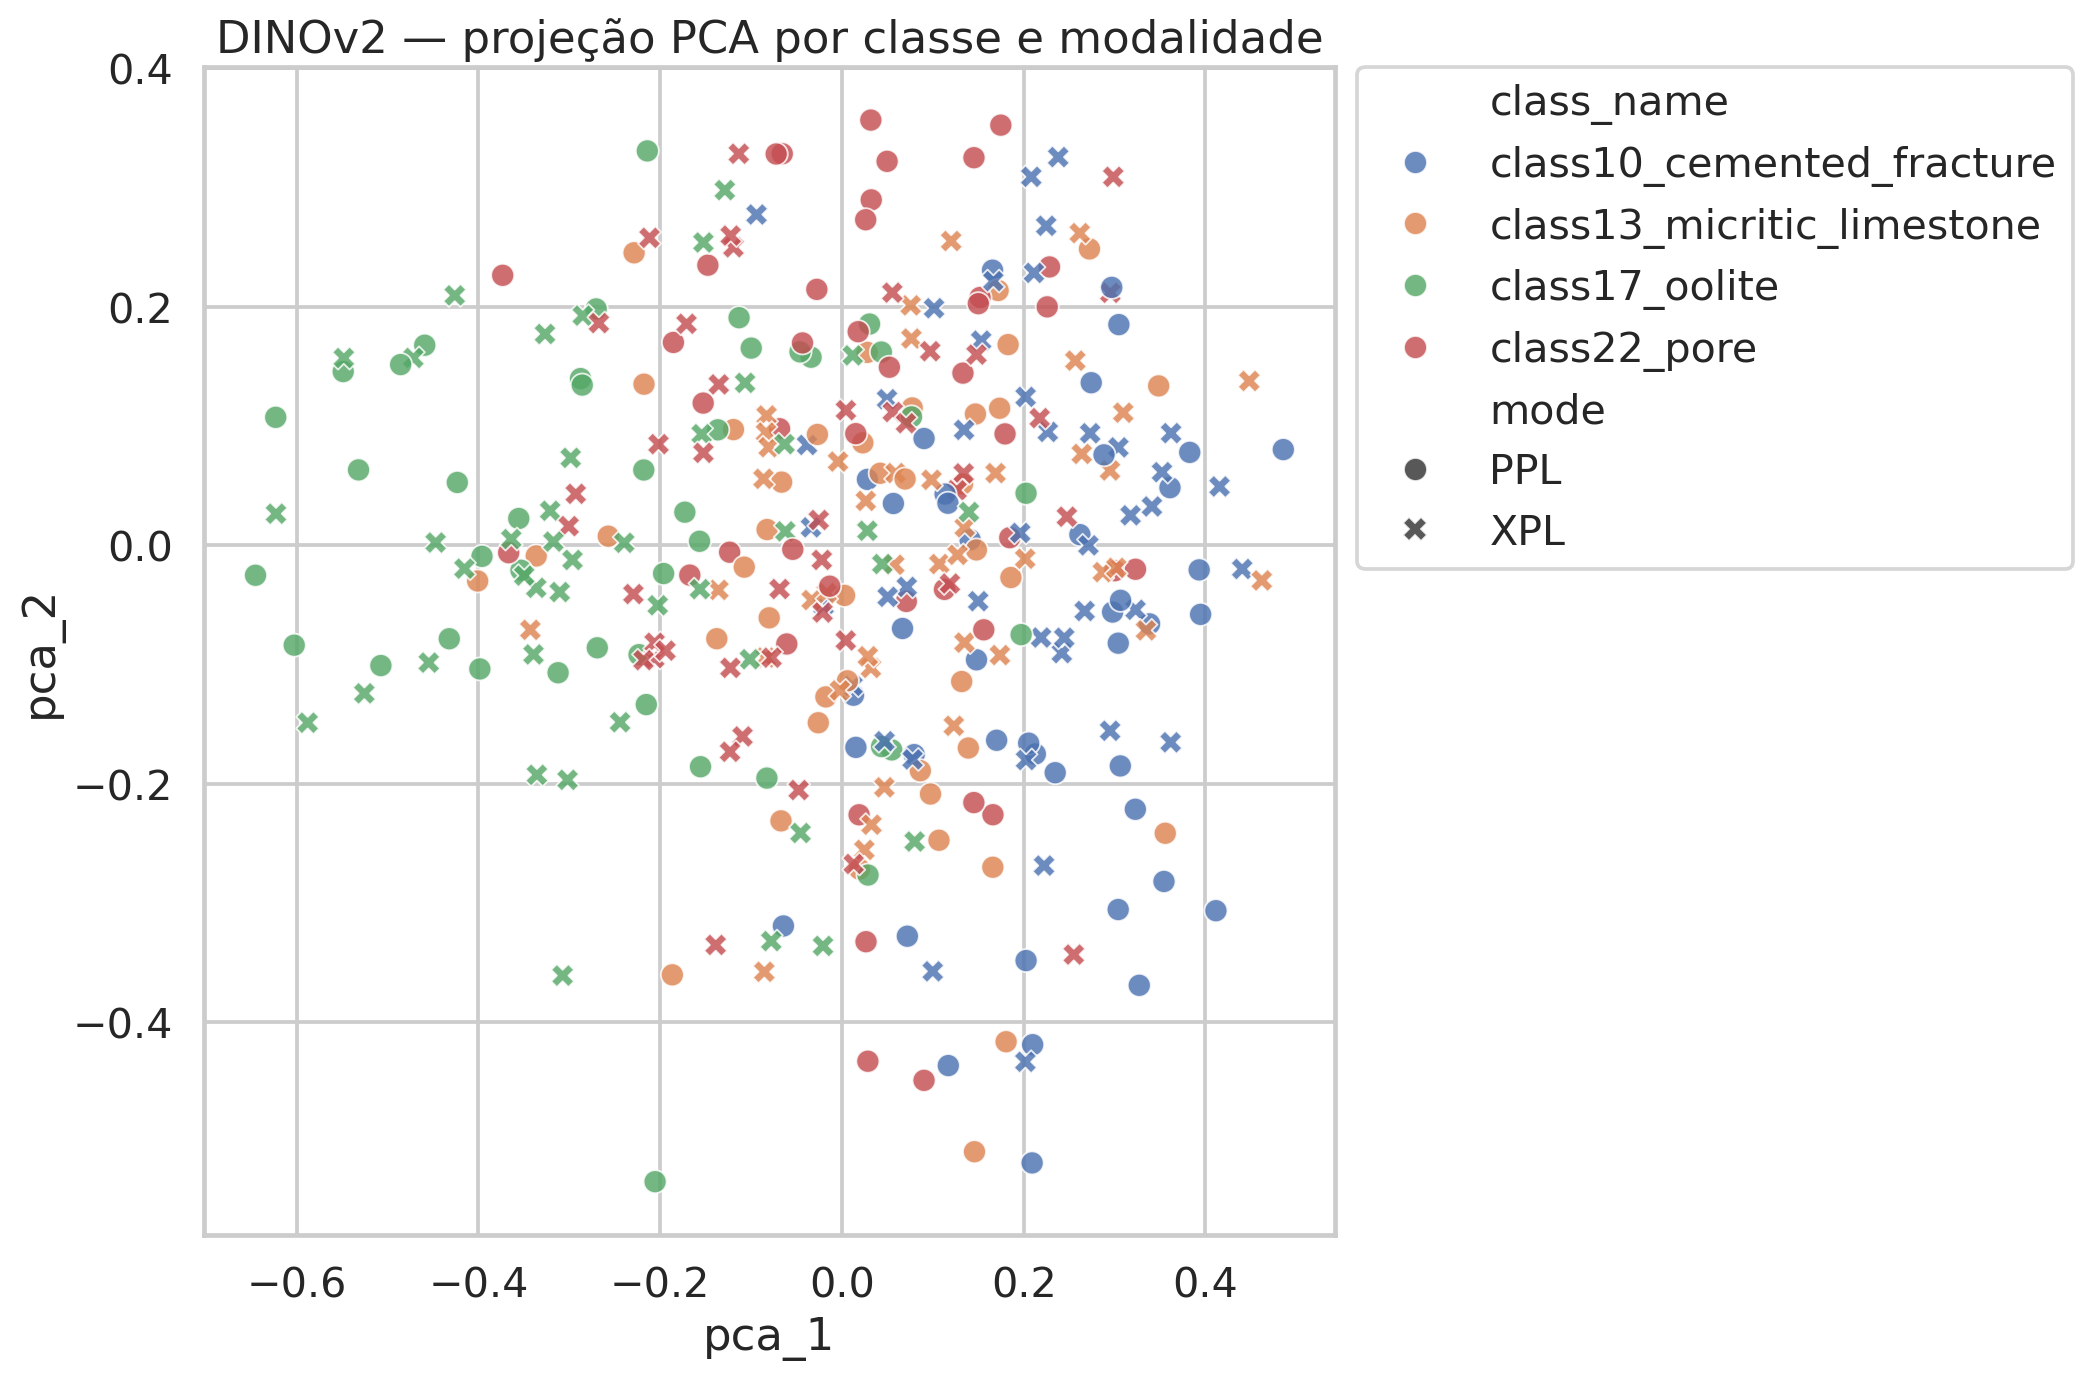

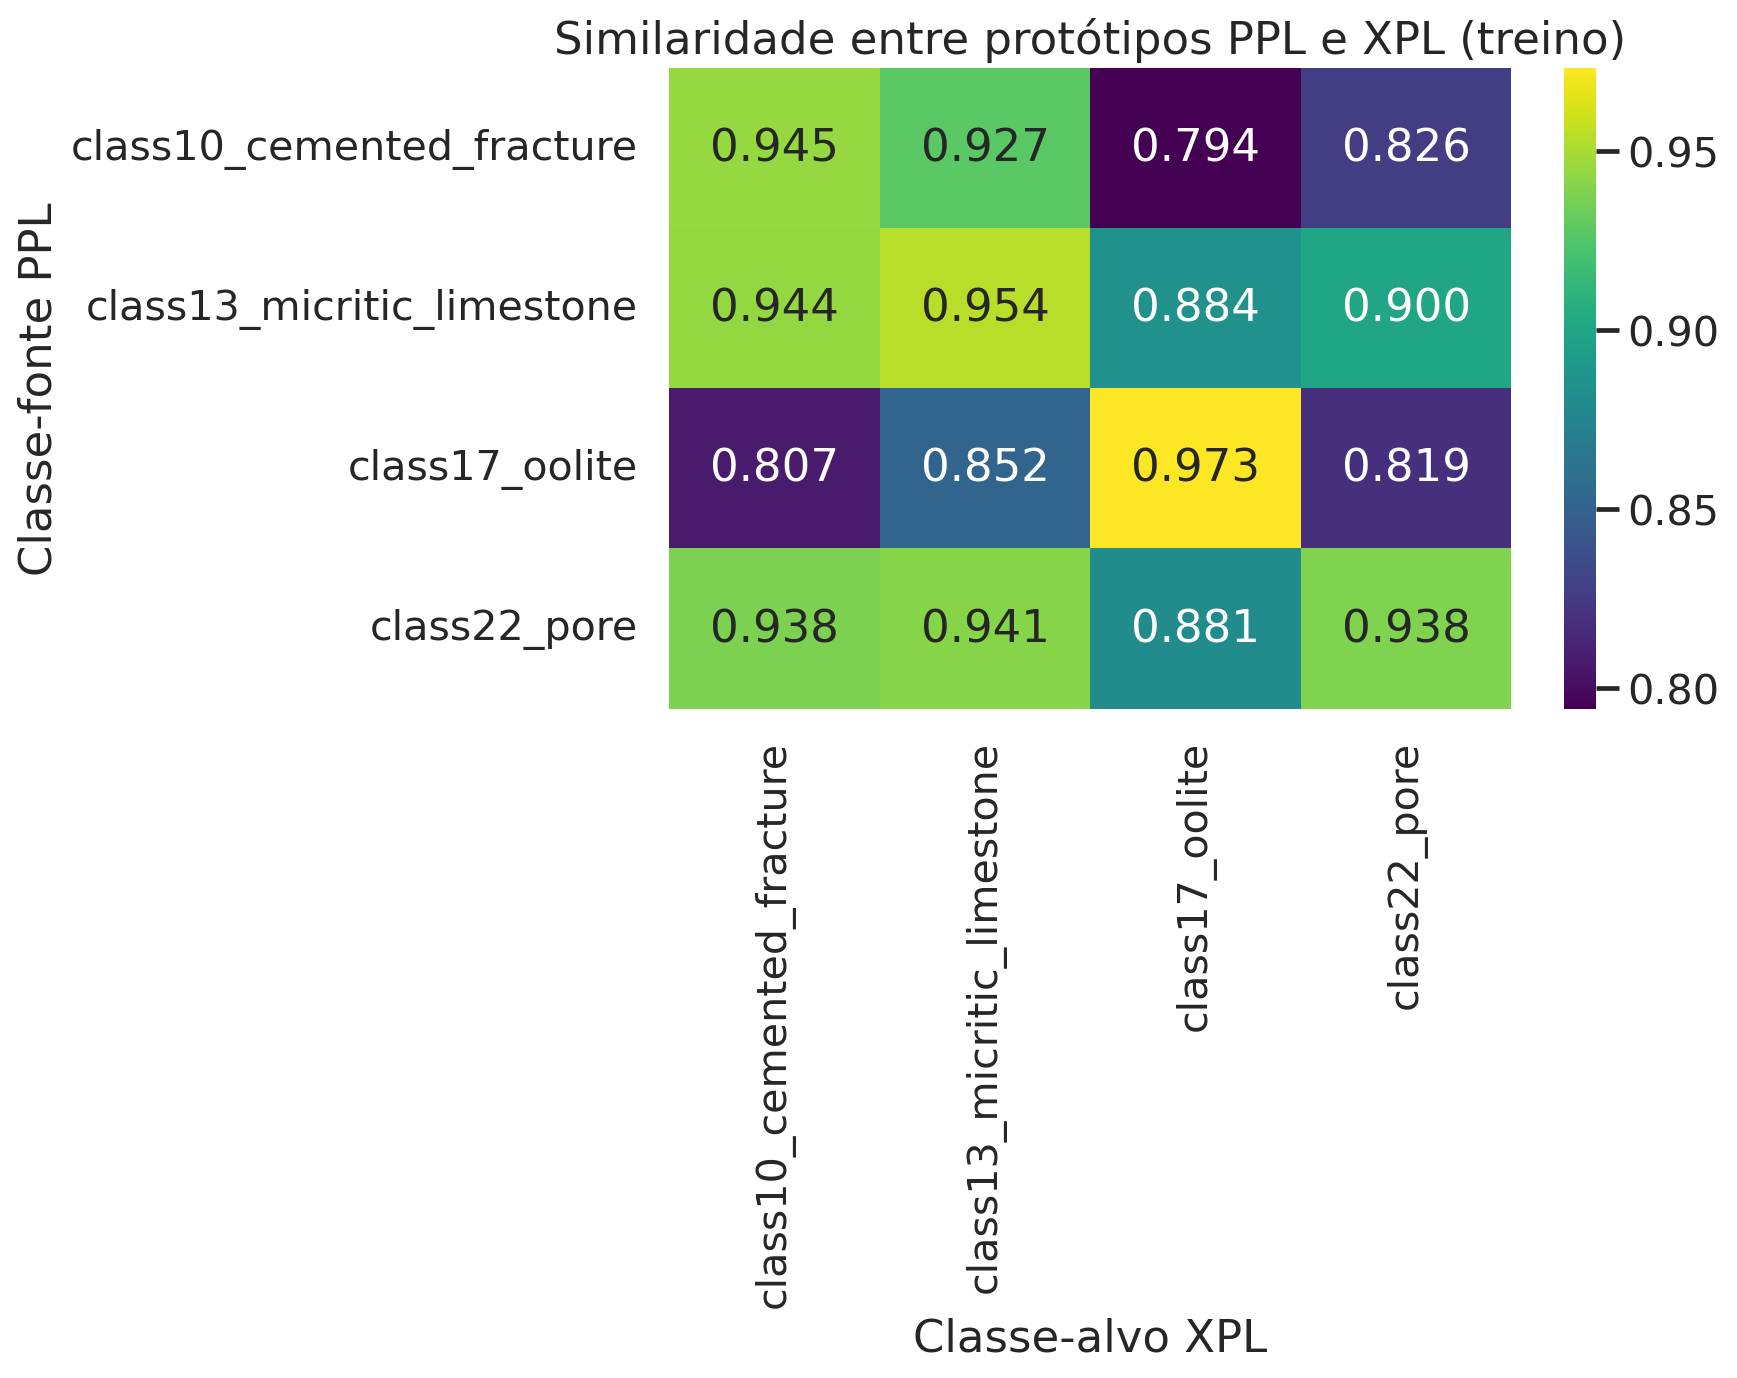

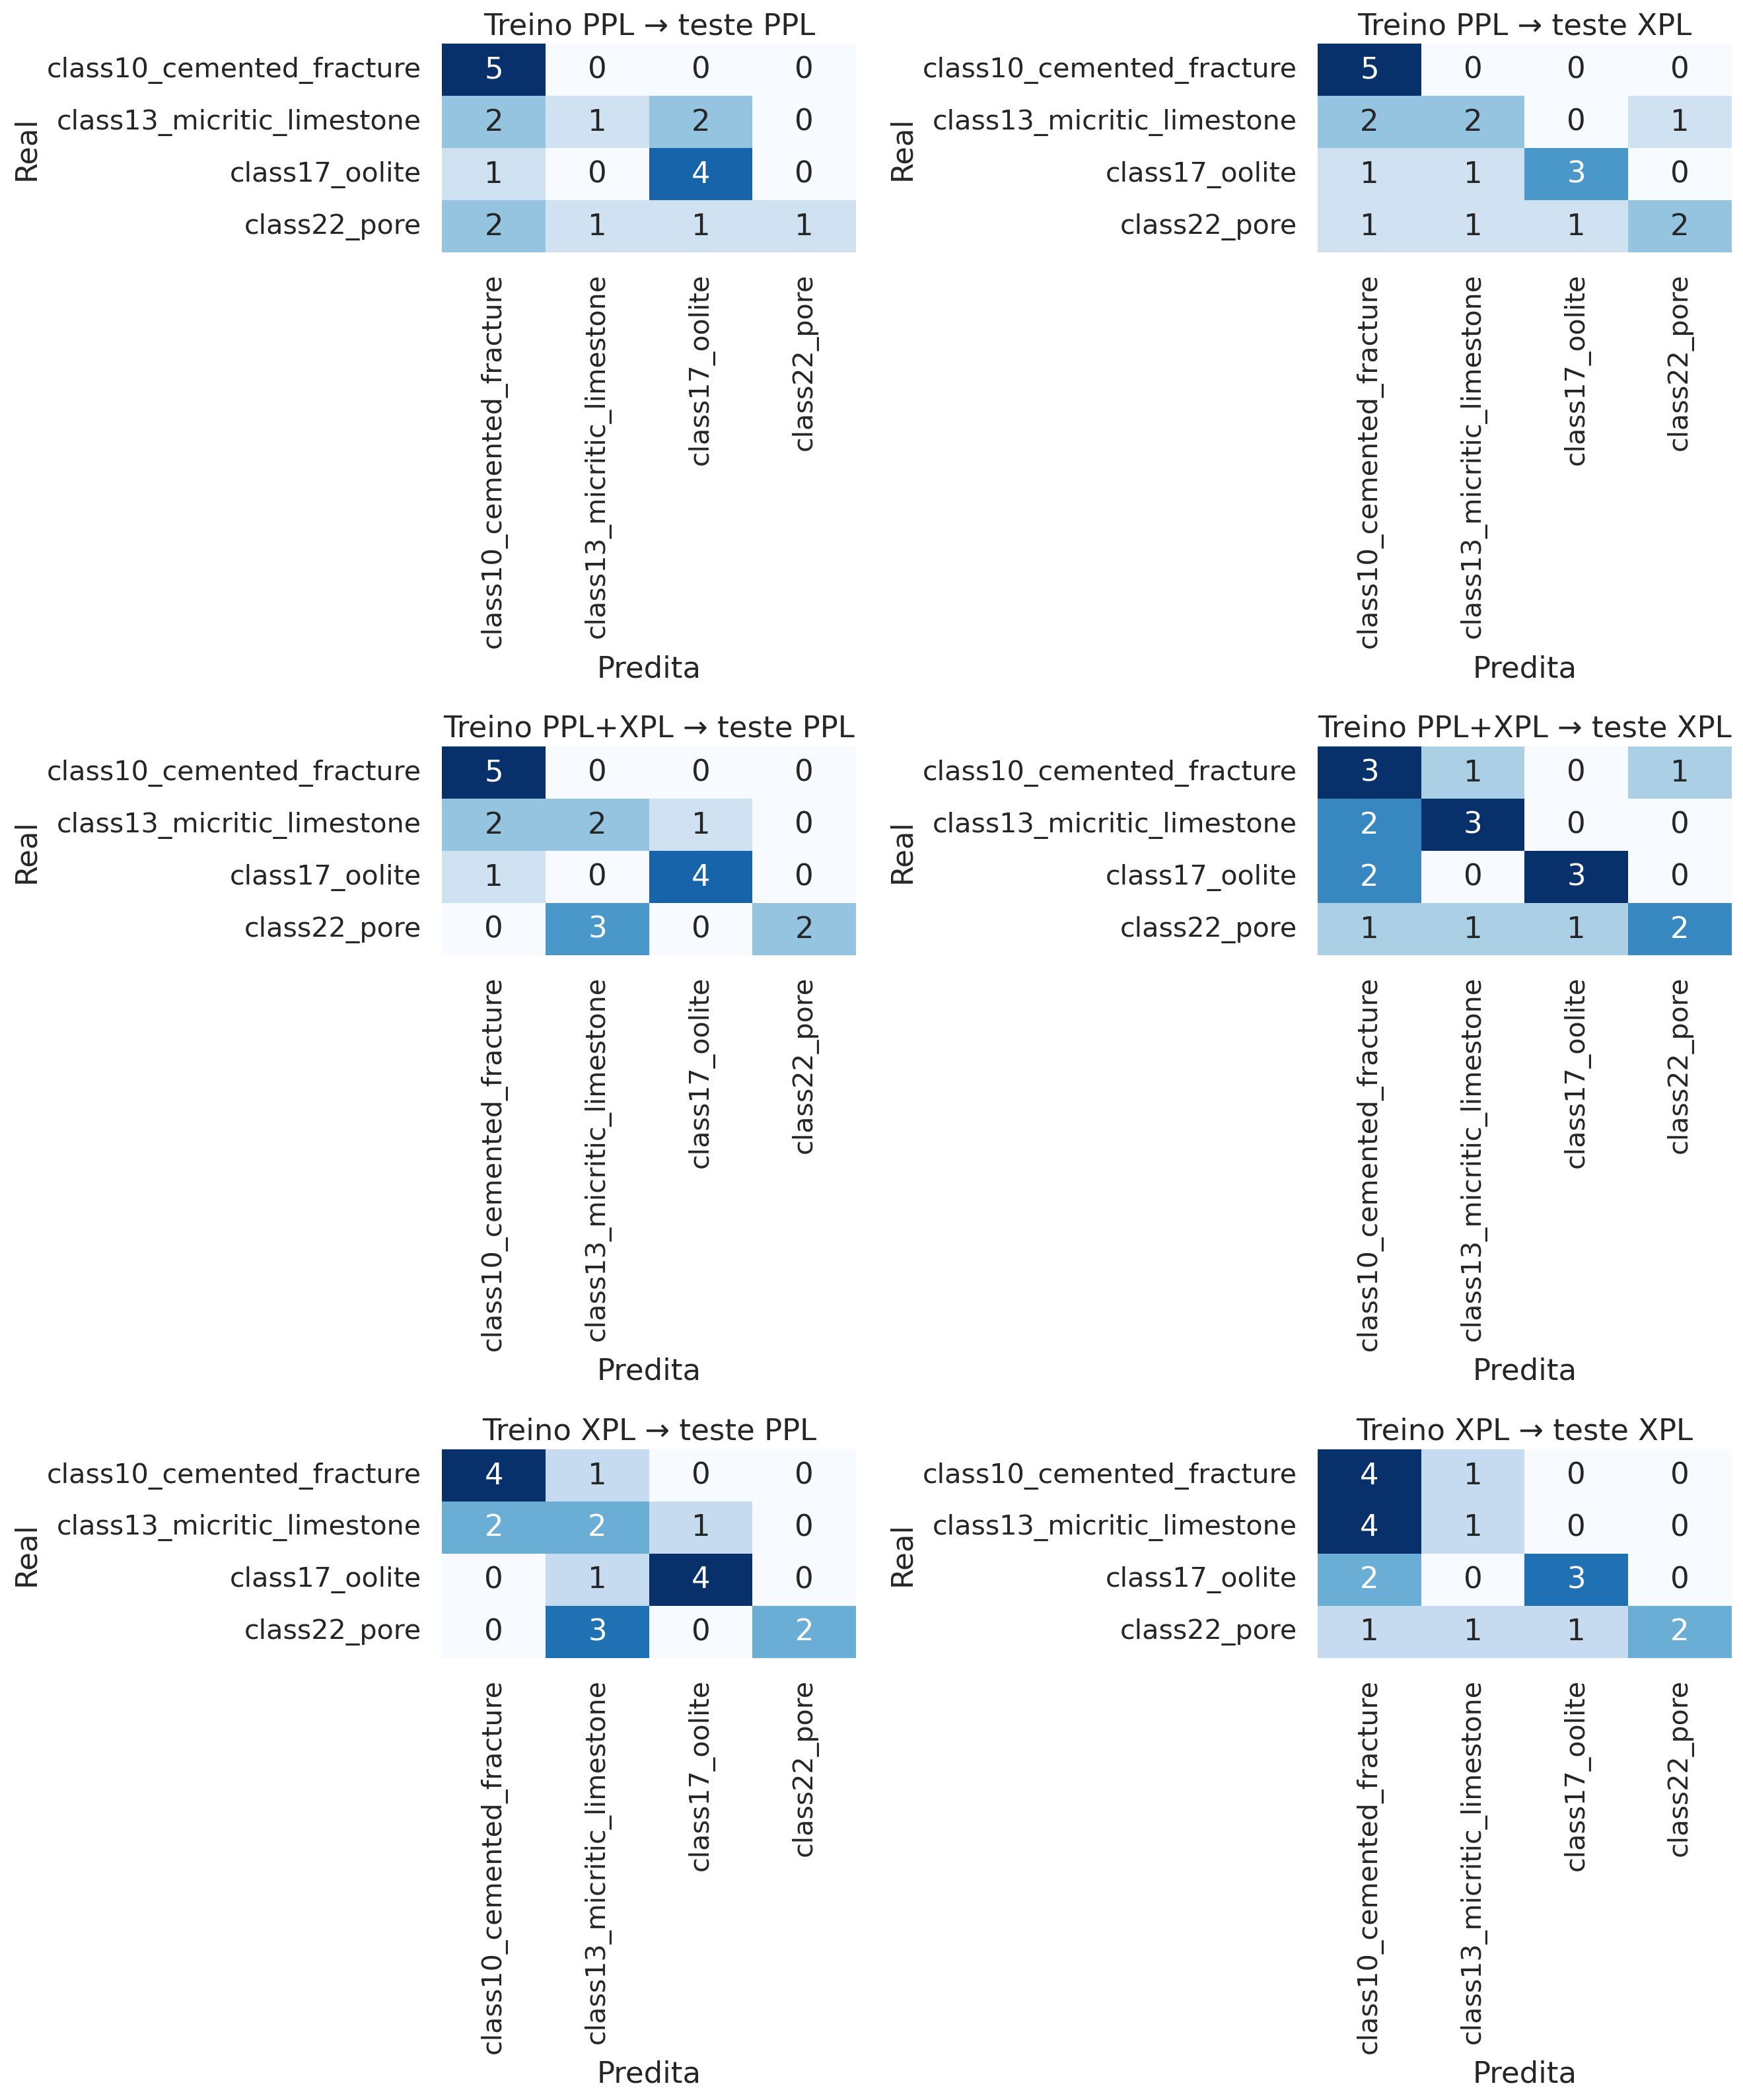

In [16]:
from IPython.display import Image as DisplayImage, display

metrics = pd.read_csv("results/dinov2/tables/linear_probe_metrics.csv")
clusters = pd.read_csv("results/dinov2/tables/clustering_metrics.csv")
display(metrics.round(3))
display(clusters.round(3))
display(DisplayImage(filename="results/dinov2/figures/pca_class_mode.png"))
display(DisplayImage(filename="results/dinov2/figures/prototype_similarity.png"))
display(DisplayImage(filename="results/dinov2/figures/linear_probe_confusions.png"))

## 8. Baixar o pacote de resultados

Guarde o ZIP e envie-o para revisão antes de publicar resultados no GitHub.

In [17]:
import shutil
from google.colab import files

archive = shutil.make_archive(
    "/content/PetroVision_DINOv2_results",
    "zip",
    root_dir="/content/PetroVision-Multimodal/results",
    base_dir="dinov2",
)
print("Pacote criado:", archive)
files.download(archive)

Pacote criado: /content/PetroVision_DINOv2_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>